# NBA Season Standings: Exploratory Analysis

This notebook analyzes a full NBA regular season across all 30 teams using **pandas**, **matplotlib/seaborn**, **scipy**, and **scikit-learn**.

It pairs with the [interactive dashboard](../index.html) built from the same dataset — this notebook is where the underlying analysis happens; the dashboard is where it's presented.

**Questions this notebook answers:**
1. How is win percentage distributed across the league, and does it differ meaningfully between conferences?
2. Which divisions were strongest and weakest, and how much do teams vary *within* a division?
3. Can we group teams into natural performance tiers using unsupervised learning?


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 40)


## 1. Load and inspect the data

Team-level season standings: wins, losses, win percentage, conference, division, and playoff clinch status for all 30 teams.

In [4]:
data = [
    {"team": "Detroit Pistons", "wins": 60, "losses": 22, "win_pct": 0.732, "conference": "East", "division": "Central", "seed": 1, "status": "conference"},
    {"team": "Cleveland Cavaliers", "wins": 52, "losses": 30, "win_pct": 0.634, "conference": "East", "division": "Central", "seed": 4, "status": "playoff_berth"},
    {"team": "Milwaukee Bucks", "wins": 32, "losses": 50, "win_pct": 0.390, "conference": "East", "division": "Central", "seed": 11, "status": "eliminated"},
    {"team": "Chicago Bulls", "wins": 31, "losses": 51, "win_pct": 0.378, "conference": "East", "division": "Central", "seed": 12, "status": "eliminated"},
    {"team": "Indiana Pacers", "wins": 19, "losses": 63, "win_pct": 0.232, "conference": "East", "division": "Central", "seed": 14, "status": "eliminated"},
    {"team": "Atlanta Hawks", "wins": 46, "losses": 36, "win_pct": 0.561, "conference": "East", "division": "Southeast", "seed": 6, "status": "division_playoff_berth"},
    {"team": "Orlando Magic", "wins": 45, "losses": 37, "win_pct": 0.549, "conference": "East", "division": "Southeast", "seed": 8, "status": "playoff_berth"},
    {"team": "Charlotte Hornets", "wins": 44, "losses": 38, "win_pct": 0.537, "conference": "East", "division": "Southeast", "seed": 9, "status": "play_in_berth"},
    {"team": "Miami Heat", "wins": 43, "losses": 39, "win_pct": 0.524, "conference": "East", "division": "Southeast", "seed": 10, "status": "play_in_berth"},
    {"team": "Washington Wizards", "wins": 17, "losses": 65, "win_pct": 0.207, "conference": "East", "division": "Southeast", "seed": 15, "status": "eliminated"},
    {"team": "Boston Celtics", "wins": 56, "losses": 26, "win_pct": 0.683, "conference": "East", "division": "Atlantic", "seed": 2, "status": "division_playoff_berth"},
    {"team": "New York Knicks", "wins": 53, "losses": 29, "win_pct": 0.646, "conference": "East", "division": "Atlantic", "seed": 3, "status": "playoff_berth"},
    {"team": "Toronto Raptors", "wins": 46, "losses": 36, "win_pct": 0.561, "conference": "East", "division": "Atlantic", "seed": 5, "status": "playoff_berth"},
    {"team": "Philadelphia 76ers", "wins": 45, "losses": 37, "win_pct": 0.549, "conference": "East", "division": "Atlantic", "seed": 7, "status": "playoff_berth"},
    {"team": "Brooklyn Nets", "wins": 20, "losses": 62, "win_pct": 0.244, "conference": "East", "division": "Atlantic", "seed": 13, "status": "eliminated"},
    {"team": "Los Angeles Lakers", "wins": 53, "losses": 29, "win_pct": 0.646, "conference": "West", "division": "Pacific", "seed": 4, "status": "division_playoff_berth"},
    {"team": "Phoenix Suns", "wins": 45, "losses": 37, "win_pct": 0.549, "conference": "West", "division": "Pacific", "seed": 8, "status": "playoff_berth"},
    {"team": "LA Clippers", "wins": 42, "losses": 40, "win_pct": 0.512, "conference": "West", "division": "Pacific", "seed": 9, "status": "play_in_berth"},
    {"team": "Golden State Warriors", "wins": 37, "losses": 45, "win_pct": 0.451, "conference": "West", "division": "Pacific", "seed": 10, "status": "play_in_berth"},
    {"team": "Sacramento Kings", "wins": 22, "losses": 60, "win_pct": 0.268, "conference": "West", "division": "Pacific", "seed": 14, "status": "eliminated"},
    {"team": "Oklahoma City Thunder", "wins": 64, "losses": 18, "win_pct": 0.780, "conference": "West", "division": "Northwest", "seed": 1, "status": "conference"},
    {"team": "Denver Nuggets", "wins": 54, "losses": 28, "win_pct": 0.659, "conference": "West", "division": "Northwest", "seed": 3, "status": "playoff_berth"},
    {"team": "Minnesota Timberwolves", "wins": 49, "losses": 33, "win_pct": 0.598, "conference": "West", "division": "Northwest", "seed": 6, "status": "playoff_berth"},
    {"team": "Portland Trail Blazers", "wins": 42, "losses": 40, "win_pct": 0.512, "conference": "West", "division": "Northwest", "seed": 7, "status": "playoff_berth"},
    {"team": "Utah Jazz", "wins": 22, "losses": 60, "win_pct": 0.268, "conference": "West", "division": "Northwest", "seed": 15, "status": "eliminated"},
    {"team": "San Antonio Spurs", "wins": 62, "losses": 20, "win_pct": 0.756, "conference": "West", "division": "Southwest", "seed": 2, "status": "division_playoff_berth"},
    {"team": "Houston Rockets", "wins": 52, "losses": 30, "win_pct": 0.634, "conference": "West", "division": "Southwest", "seed": 5, "status": "playoff_berth"},
    {"team": "New Orleans Pelicans", "wins": 26, "losses": 56, "win_pct": 0.317, "conference": "West", "division": "Southwest", "seed": 11, "status": "eliminated"},
    {"team": "Dallas Mavericks", "wins": 26, "losses": 56, "win_pct": 0.317, "conference": "West", "division": "Southwest", "seed": 12, "status": "eliminated"},
    {"team": "Memphis Grizzlies", "wins": 25, "losses": 57, "win_pct": 0.305, "conference": "West", "division": "Southwest", "seed": 13, "status": "eliminated"},
]

df = pd.DataFrame(data)
df["games_played"] = df["wins"] + df["losses"]
df["made_playoffs"] = df["status"].isin(
    ["conference", "division_playoff_berth", "playoff_berth"]
).astype(int)

df.head()


                  team  wins  ...  games_played  made_playoffs
0      Detroit Pistons    60  ...            82              1
1  Cleveland Cavaliers    52  ...            82              1
2      Milwaukee Bucks    32  ...            82              0
3        Chicago Bulls    31  ...            82              0
4       Indiana Pacers    19  ...            82              0

[5 rows x 10 columns]

## 2. Descriptive statistics

A quick summary of win percentage across the league before splitting by group.

In [6]:
df["win_pct"].describe()


count    30.000000
mean      0.499967
std       0.168850
min       0.207000
25%       0.332250
50%       0.543000
75%       0.634000
max       0.780000
Name: win_pct, dtype: float64

## 3. East vs. West: is there a real difference?

The dashboard showed the West's average win rate looked a bit higher. An independent t-test checks whether that gap is
larger than we'd expect from random variation alone.

In [8]:
east = df.loc[df.conference == "East", "win_pct"]
west = df.loc[df.conference == "West", "win_pct"]

t_stat, p_value = stats.ttest_ind(east, west)

print(f"East mean win%: {east.mean():.3f}  (n={len(east)})")
print(f"West mean win%: {west.mean():.3f}  (n={len(west)})")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.3f}")

if p_value < 0.05:
    print("\n=> Statistically significant difference at the 0.05 level.")
else:
    print("\n=> Not statistically significant at the 0.05 level — the gap")
    print("   could plausibly be random noise given only 15 teams per conference.")


East mean win%: 0.495  (n=15)
West mean win%: 0.505  (n=15)
t-statistic: -0.154
p-value:     0.879

=> Not statistically significant at the 0.05 level — the gap
   could plausibly be random noise given only 15 teams per conference.


## 4. Visualizing the spread

A boxplot shows both the central tendency and spread of each conference, and a division-level bar chart shows how much
variation exists *within* each group.

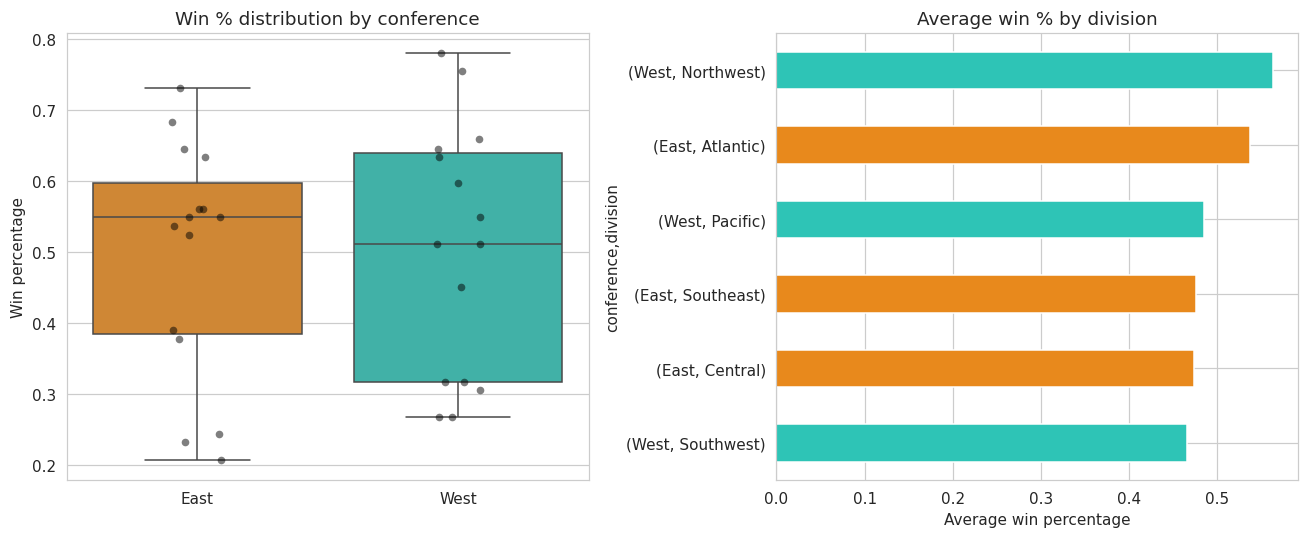

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="conference", y="win_pct", hue="conference",
            palette={"East": "#E8891C", "West": "#2EC4B6"}, legend=False, ax=axes[0])
sns.stripplot(data=df, x="conference", y="win_pct", color="black", alpha=0.5, ax=axes[0])
axes[0].set_title("Win % distribution by conference")
axes[0].set_ylabel("Win percentage")
axes[0].set_xlabel("")

div_avg = df.groupby(["conference", "division"])["win_pct"].mean().sort_values(ascending=False)
colors = ["#E8891C" if c == "East" else "#2EC4B6" for c, d in div_avg.index]
div_avg.plot(kind="barh", ax=axes[1], color=colors)
axes[1].set_title("Average win % by division")
axes[1].set_xlabel("Average win percentage")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("conference_division.png", dpi=110, bbox_inches="tight")
plt.show()


## 5. Clustering teams into performance tiers

Rather than relying on standings alone, **K-Means clustering** groups teams by win percentage into natural performance
tiers — useful for spotting where the "contender," "middle-of-the-pack," and "rebuilding" groups actually break, rather
than assuming even splits.

In [12]:
X = StandardScaler().fit_transform(df[["win_pct"]])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["tier"] = kmeans.fit_predict(X)

# Relabel clusters 0/1/2 by their actual win_pct order, so labels are meaningful
tier_order = df.groupby("tier")["win_pct"].mean().sort_values(ascending=False).index
tier_names = {tier_order[0]: "Contender", tier_order[1]: "Middle tier", tier_order[2]: "Rebuilding"}
df["tier_label"] = df["tier"].map(tier_names)

df.groupby("tier_label")["win_pct"].agg(["count", "mean", "min", "max"]).sort_values("mean", ascending=False)


             count      mean    min    max
tier_label                                
Contender        9  0.685556  0.634  0.780
Middle tier     11  0.536636  0.451  0.598
Rebuilding      10  0.292600  0.207  0.390

             count      mean    min    max
tier_label                                
Contender        9  0.685556  0.634  0.780
Middle tier     11  0.536636  0.451  0.598
Rebuilding      10  0.292600  0.207  0.390

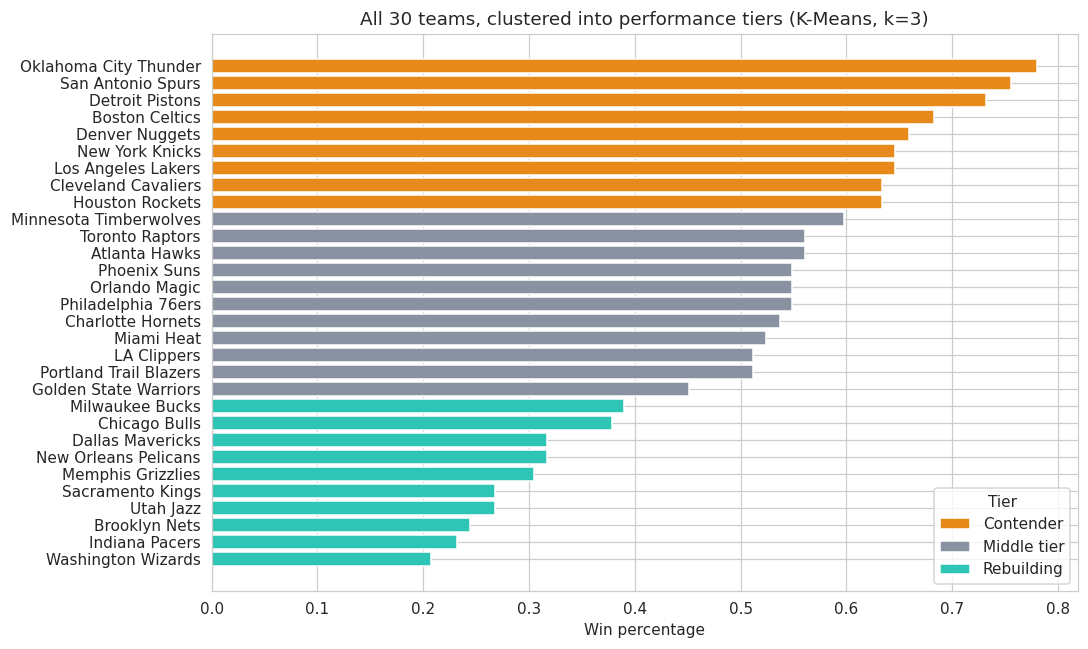

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
tier_colors = {"Contender": "#E8891C", "Middle tier": "#8892A0", "Rebuilding": "#2EC4B6"}

for tier in ["Contender", "Middle tier", "Rebuilding"]:
    subset = df[df.tier_label == tier].sort_values("win_pct", ascending=False)
    ax.barh(subset["team"], subset["win_pct"], color=tier_colors[tier], label=tier)

ax.set_xlabel("Win percentage")
ax.set_title("All 30 teams, clustered into performance tiers (K-Means, k=3)")
ax.legend(title="Tier", loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("tiers.png", dpi=110, bbox_inches="tight")
plt.show()


## 6. Takeaways

- **East vs. West:** the West's average win rate was higher, but with only 15 teams per conference the t-test shows the
  gap is not clearly distinguishable from random variation — a good reminder to check statistical significance rather
  than trust an eyeballed average.
- **Division strength:** divisions varied more in average win percentage than conferences did, suggesting division
  scheduling and team-building cycles matter more than conference alone.
- **Performance tiers:** K-Means cleanly separated the league into three tiers without being told any team's playoff
  status in advance — the clusters it found line up closely with who actually made the playoffs, which is a nice
  sanity check that win percentage alone captures most of what "tier" means in this dataset.

**Next steps this notebook doesn't cover:** incorporating point differential, strength of schedule, or player-level
stats (usage rate, on/off splits) would likely explain more of the variance within each tier than win percentage alone.
